In [17]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


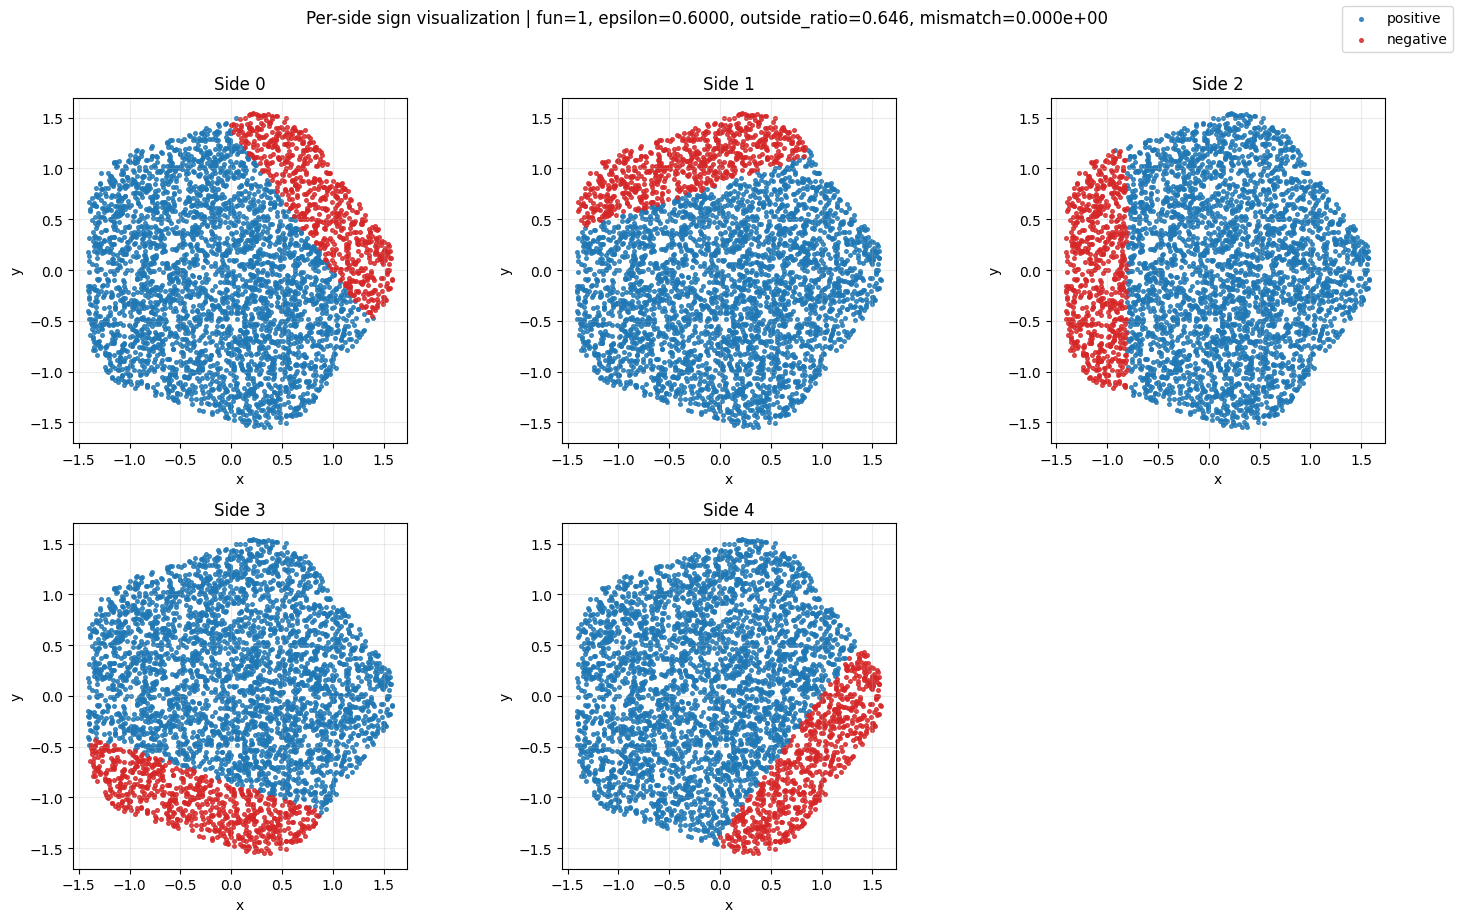

(<Figure size 1500x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Side 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 1'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 2'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Side 3'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Side 4'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 {'batch_size': 4000,
  'fun_num': 1,
  'epsilon': 0.6,
  'n_sides_out': 5,
  'outside_ratio': 0.6455000042915344,
  'mismatch_ratio': 0.0})

In [23]:
NI.visualize_epsilon_side_signs(fun_num=1,epsilon=0.6)

In [66]:
architecture = [2, 256,256,256,256,5]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.7)
#model.lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(model.optimizer, gamma=0.992)
#model.lr_scheduler = torch.optim.lr_scheduler.MultiplicativeLR(model.optimizer, lr_lambda=lambda epoch: 0.995)
#model.lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(model.optimizer, T_max=1000, eta_min=0)


Number of parameters: 199429


In [60]:
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=100, gamma=1.2)

In [72]:
importlib.reload(NI)
NUM_EPOCHS = 1000
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0,
                      hotspot_coeff=0.0,
                      use_scheduler=True,
                      epsilon=0.2, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.0007278545539279882, Acc: 0.0007278545539279882
Epoch [99], Loss: 0.0006085328167968279, Acc: 0.0006085328167968279
Epoch [199], Loss: 0.0007316772931081616, Acc: 0.0007316772931081616
Epoch [299], Loss: 0.0006443231147502776, Acc: 0.0006443231147502776
Epoch [399], Loss: 0.0006451327164624782, Acc: 0.0006451327164624782
Epoch [499], Loss: 0.0005051536315669296, Acc: 0.0005051536315669296
Epoch [599], Loss: 0.00040897795914268215, Acc: 0.00040897795914268215
Epoch [699], Loss: 0.0006036723050377189, Acc: 0.0006036723050377189
Epoch [799], Loss: 0.0006123738195155055, Acc: 0.0006123738195155055
Epoch [899], Loss: 0.0006772644661409906, Acc: 0.0006772644661409906
Epoch [999], Loss: 0.0007323884677451188, Acc: 0.0007323884677451188


In [335]:
importlib.reload(NI)
NUM_EPOCHS = 10000
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=1.0,
                      eikon_coeff=1e-3,
                      hotspot_coeff=1e-3,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.44326759936497906, Acc: 0.4009590048526682
Epoch [999], Loss: 0.0034838847478292235, Acc: 0.0012861235450433337
Epoch [1999], Loss: 0.002703393567107631, Acc: 0.0008721699431427996
Epoch [2999], Loss: 0.0015179730509704825, Acc: 0.00032739099823014323
Epoch [3999], Loss: 0.0013312009001407409, Acc: 0.00021902564424792164
Epoch [4999], Loss: 0.0011223598161969831, Acc: 0.00013821276249611025
Epoch [5999], Loss: 0.0011022453892192555, Acc: 0.0001221754595186803
Epoch [6999], Loss: 0.0010484422745921519, Acc: 9.956402468140771e-05
Epoch [7999], Loss: 0.0010477070062698203, Acc: 0.00010669604882721515
Epoch [8999], Loss: 0.001039194040980692, Acc: 9.920389645918658e-05
Epoch [9999], Loss: 0.0010338025244706148, Acc: 9.699454421645723e-05


In [51]:
#pritn model datatype
print(model.parameters().__next__().dtype)

torch.float64


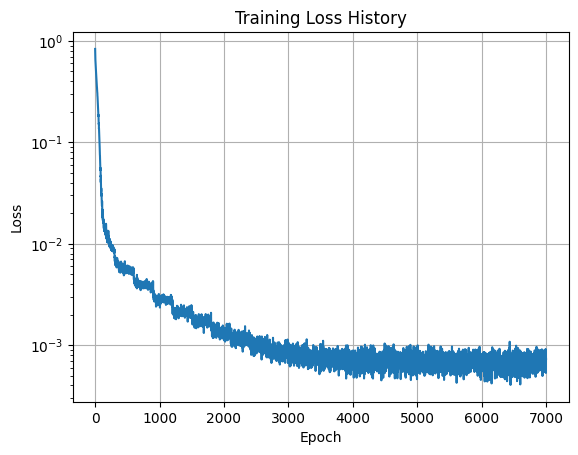

In [73]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [29]:
importlib.reload(NI)
NI.evaluate_model_random_points(model, function_case=1,N=30000)

Model evaluation on N=30000 random points (function_case=1):
  Value errors: mean_abs=2.141312e-04, max_abs=3.391008e-02, L2=6.343618e-04
  Grad-norm errors (|grad|-1): mean_abs=1.273478e-02, max_abs=9.820029e-01, L2=3.966167e-02
  Hessian-diagonal errors (target 0): mean_abs=8.503743e-01, max_abs=3.084596e+01, L2=1.842574e+00
  General (closest-side) errors: MAE=1.814770e-04, L_inf=9.144264e-03


{'N': 30000,
 'function_case': 1,
 'global': {'value_mean_abs_error': 0.00021413124639628516,
  'value_max_abs_error': 0.03391008089547398,
  'value_l2_error': 0.0006343617784033508,
  'grad_norm_mean_abs_error': 0.01273478367866385,
  'grad_norm_max_abs_error': 0.9820029397791501,
  'grad_norm_l2_error': 0.03966167435740653,
  'hessian_diag_mean_abs_error': 0.8503743103687081,
  'hessian_diag_max_abs_error': 30.84595986572068,
  'hessian_diag_l2_error': 1.842574377569655,
  'general_closest_side_mae': 0.00018147703371096082,
  'general_closest_side_l_inf': 0.009144264309287652}}

In [116]:
model.lr_scheduler.get_lr()

[1.511157274518289e-07]

In [117]:

x, y = NI.generate_data(batch_size=1024, fun_num=1, device=torch.device('cpu'))
criterion = torch.nn.L1Loss()
# Save parameters before update
old_params = [p.detach().clone() for p in model.parameters()]

# Training step
model.optimizer.zero_grad()
loss = criterion(model(x), y)
loss.backward()

total_grad = 0.0
total_elements = 0

for p in model.parameters():
    if p.grad is not None:
        total_grad += p.grad.abs().sum().item()
        total_elements += p.grad.numel()

avg_grad = total_grad / total_elements

print(f"Average gradient magnitude: {avg_grad:.6e}")

model.optimizer.step()

# Compute average parameter change
total_change = 0.0
total_elements = 0

for old_p, new_p in zip(old_params, model.parameters()):
    change = (new_p - old_p).abs()
    total_change += change.sum().item()
    total_elements += change.numel()

avg_change = total_change / total_elements

print(f"Average parameter change: {avg_change:.6e}")

Average gradient magnitude: 9.001354e-04
Average parameter change: 1.208160e-08


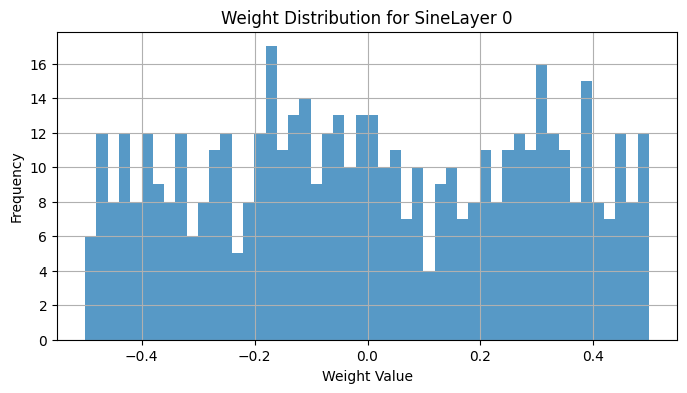

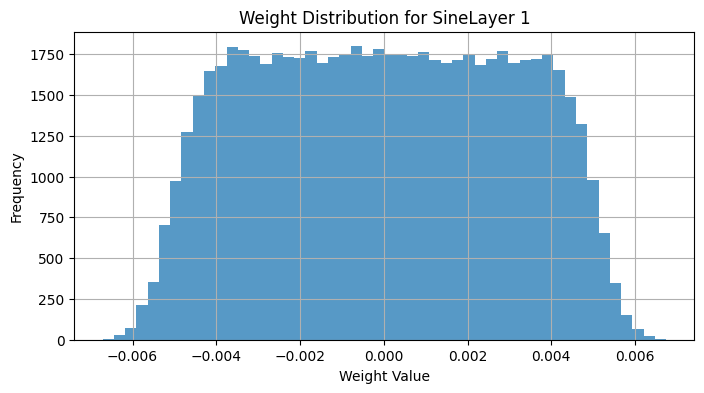

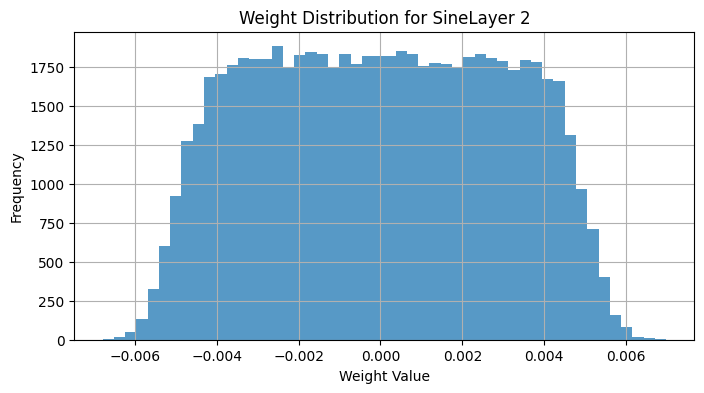

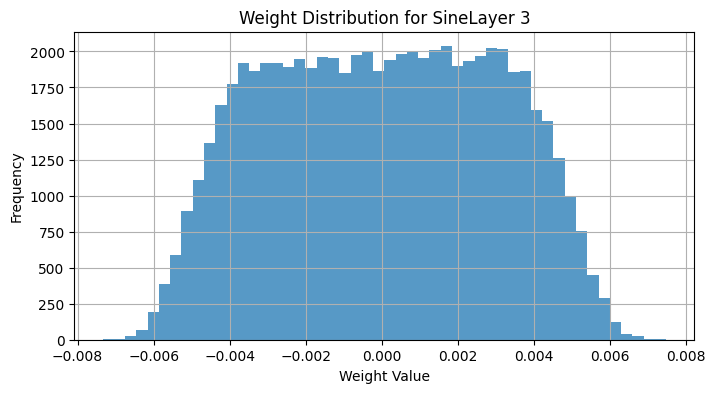

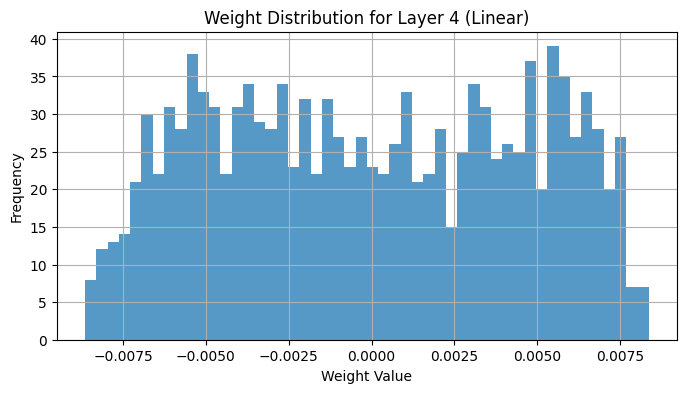

In [35]:
NI.plot_model_weight_per_layer_hyst(model)

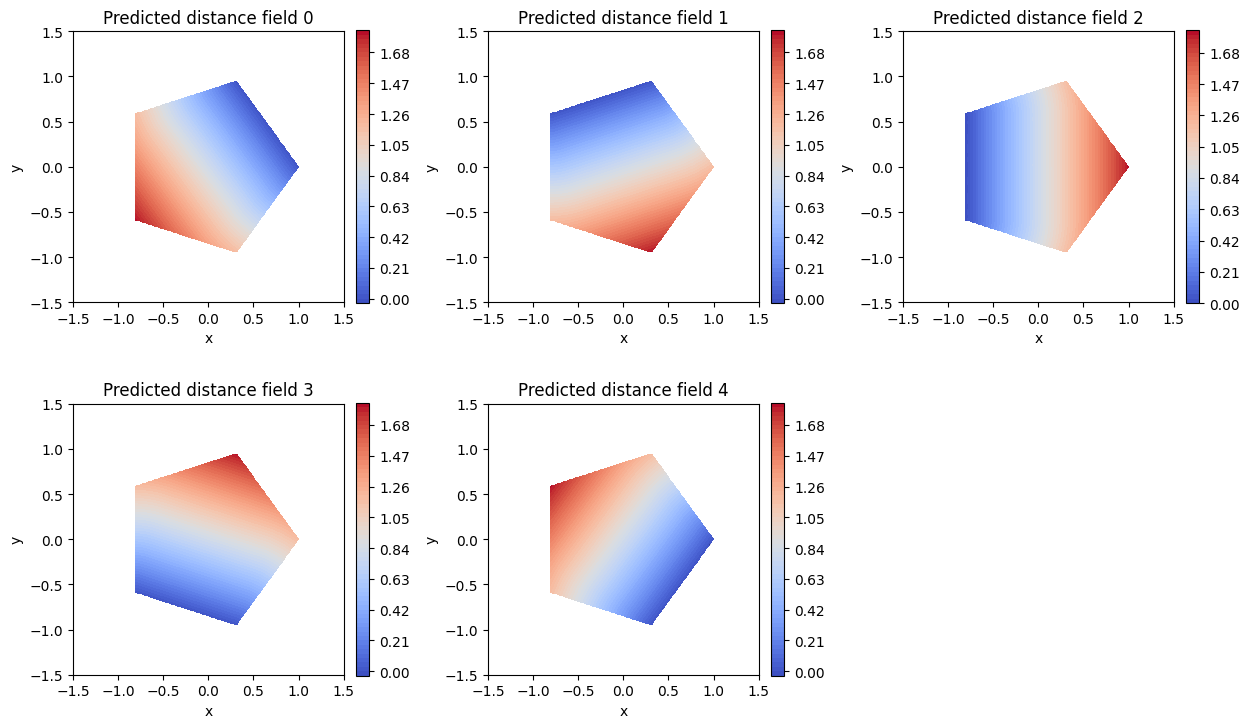

In [74]:
_=NI.plot_nn_distance_fields(model,extent=[-1.5,1.5,-1.5,1.5], device=torch.device('cpu'), mask_outside_domain=True)

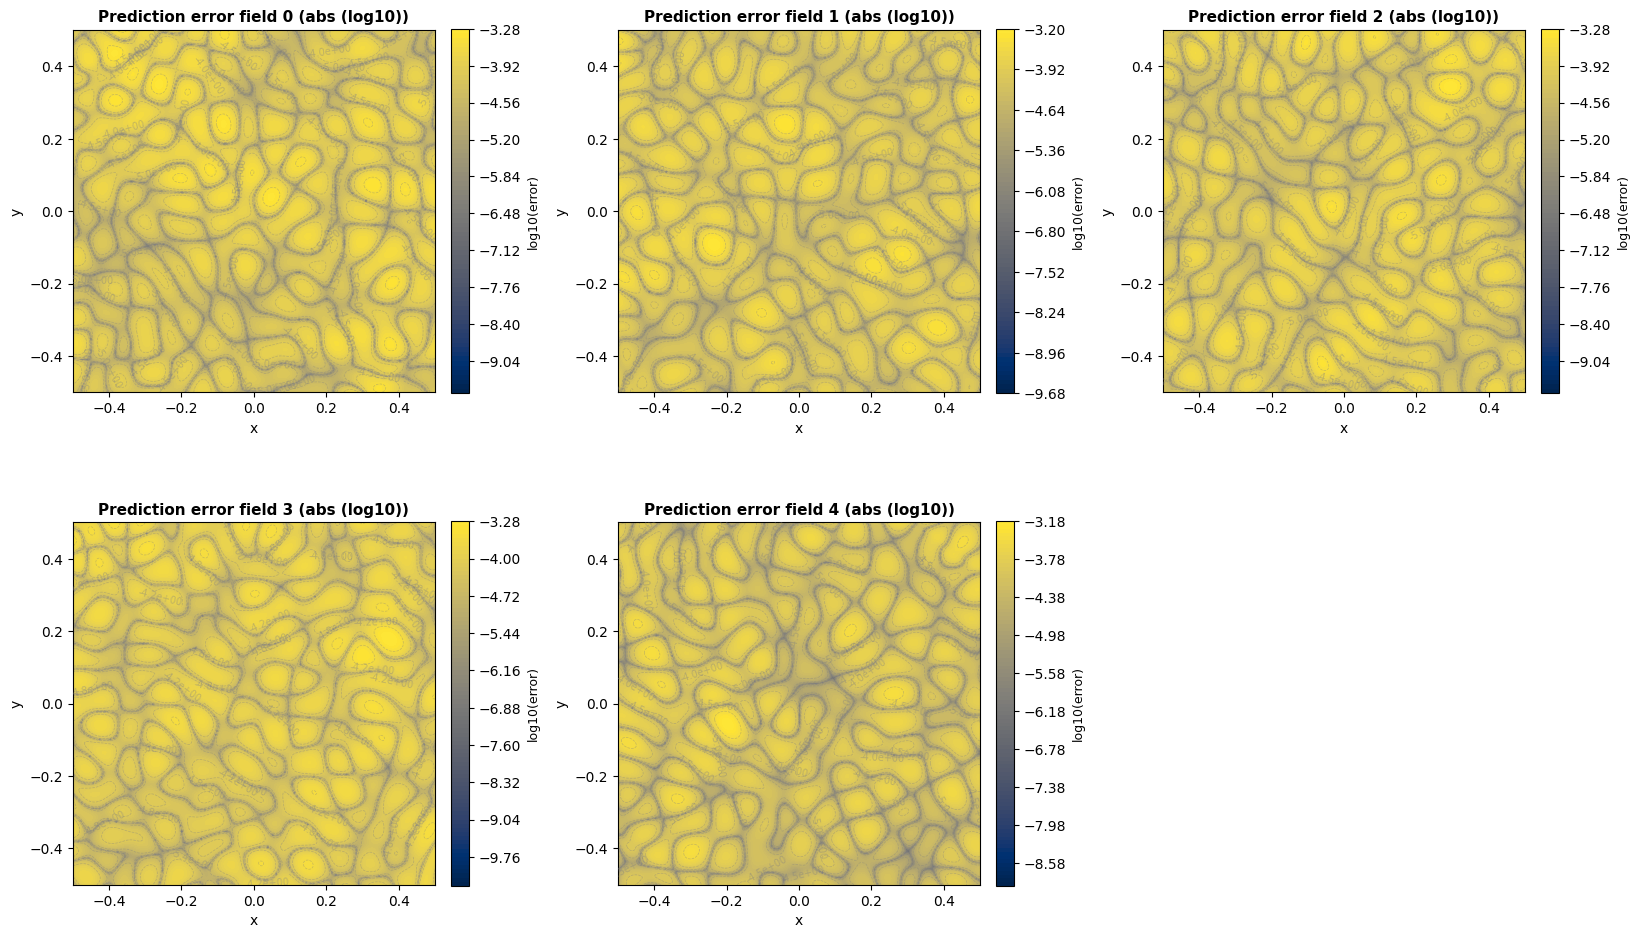

In [75]:
_=NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'), cmap='cividis')

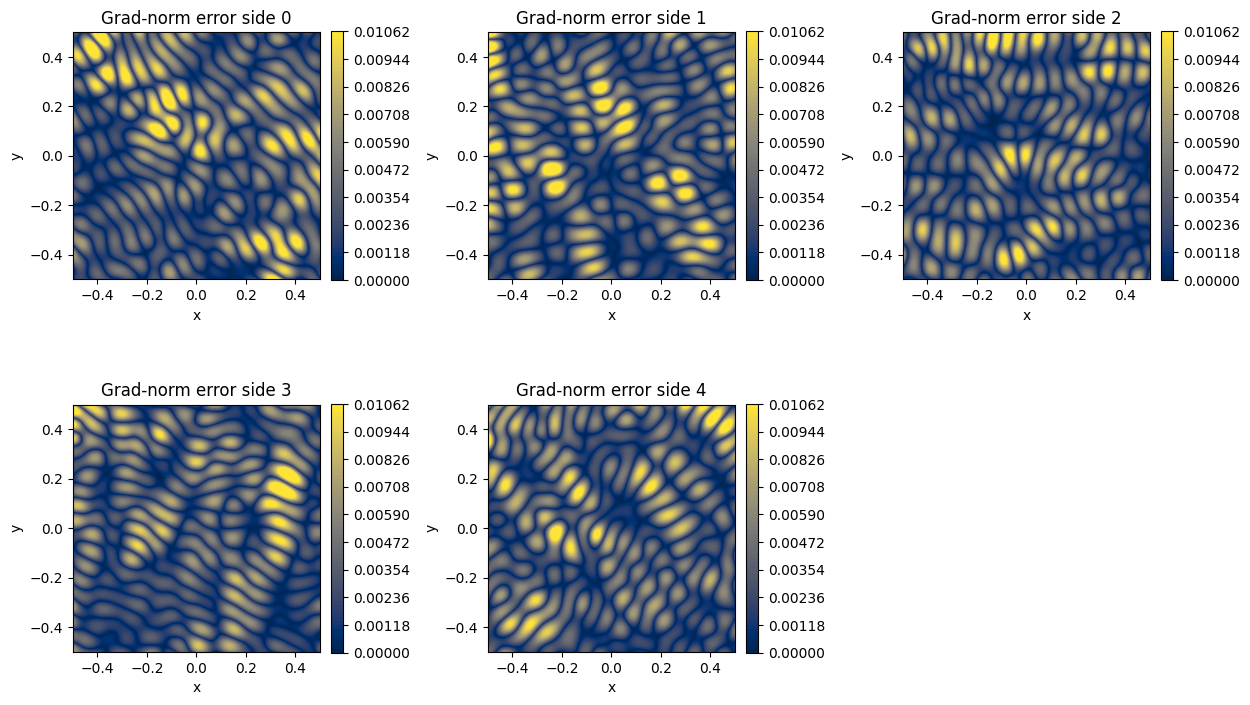

In [76]:
_=NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'), cmap='cividis')

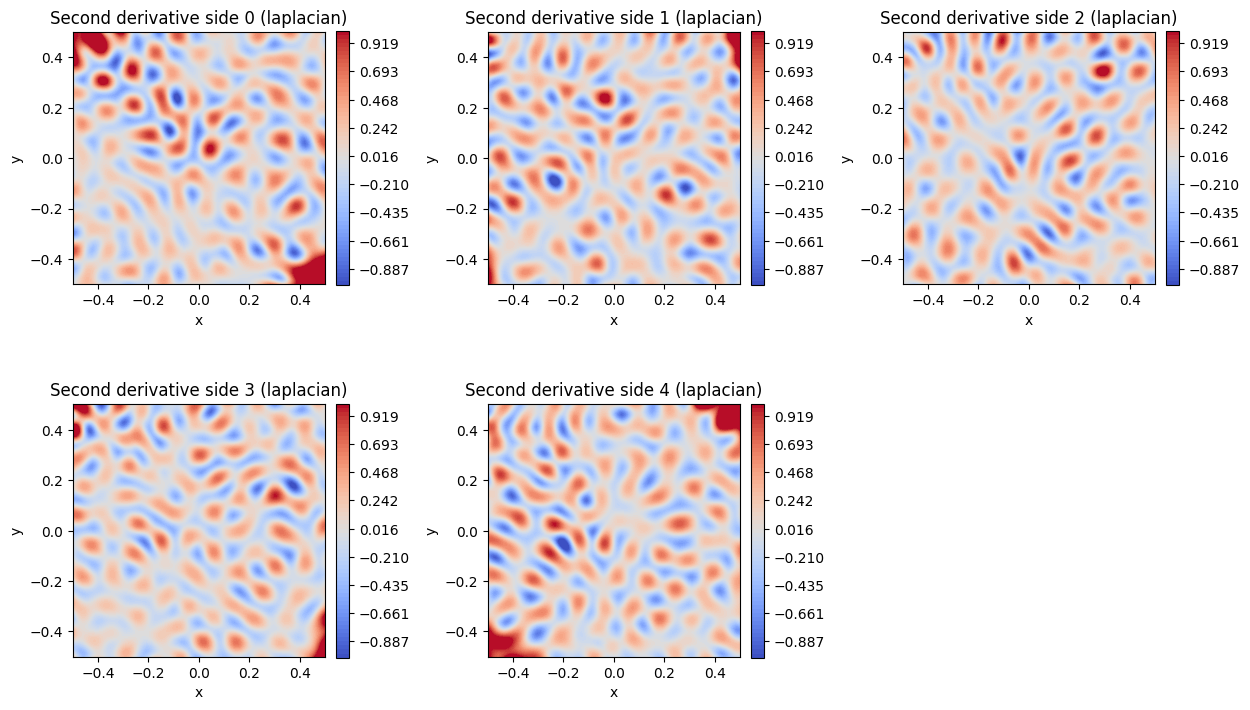

In [77]:
_=NI.plot_local_per_side_second_derivative(model=model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

In [12]:
_=NI.evaluate_gradient_errors_random_points_fun1(model, N=30000)

Gradient-error evaluation on N=30000 random points (function_case=1):
  Length error: mean_abs=2.622434e-02, max_abs=9.947983e-01, L2=4.747652e-02
  Direction error (1-cos): mean_abs=1.443758e-03, max_abs=1.999779e+00, L2=3.434467e-02
  Closest-side length mean_abs=2.230035e-02, max_abs=2.344245e-01
  Closest-side direction mean_abs=2.771446e-04, max_abs=4.642029e-02
  Side 0: len(mean_abs=2.726457e-02, max_abs=9.947983e-01, L2=4.579337e-02) | dir(mean_abs=9.518438e-04, max_abs=1.868052e+00, L2=1.974554e-02)
  Side 1: len(mean_abs=2.367157e-02, max_abs=9.915490e-01, L2=4.569953e-02) | dir(mean_abs=1.685751e-03, max_abs=1.999745e+00, L2=4.277164e-02)
  Side 2: len(mean_abs=3.021045e-02, max_abs=9.607862e-01, L2=5.271448e-02) | dir(mean_abs=2.187139e-03, max_abs=1.999537e+00, L2=4.794440e-02)
  Side 3: len(mean_abs=2.290066e-02, max_abs=9.825448e-01, L2=4.369255e-02) | dir(mean_abs=7.191450e-04, max_abs=1.750634e+00, L2=1.169433e-02)
  Side 4: len(mean_abs=2.707447e-02, max_abs=9.497828e

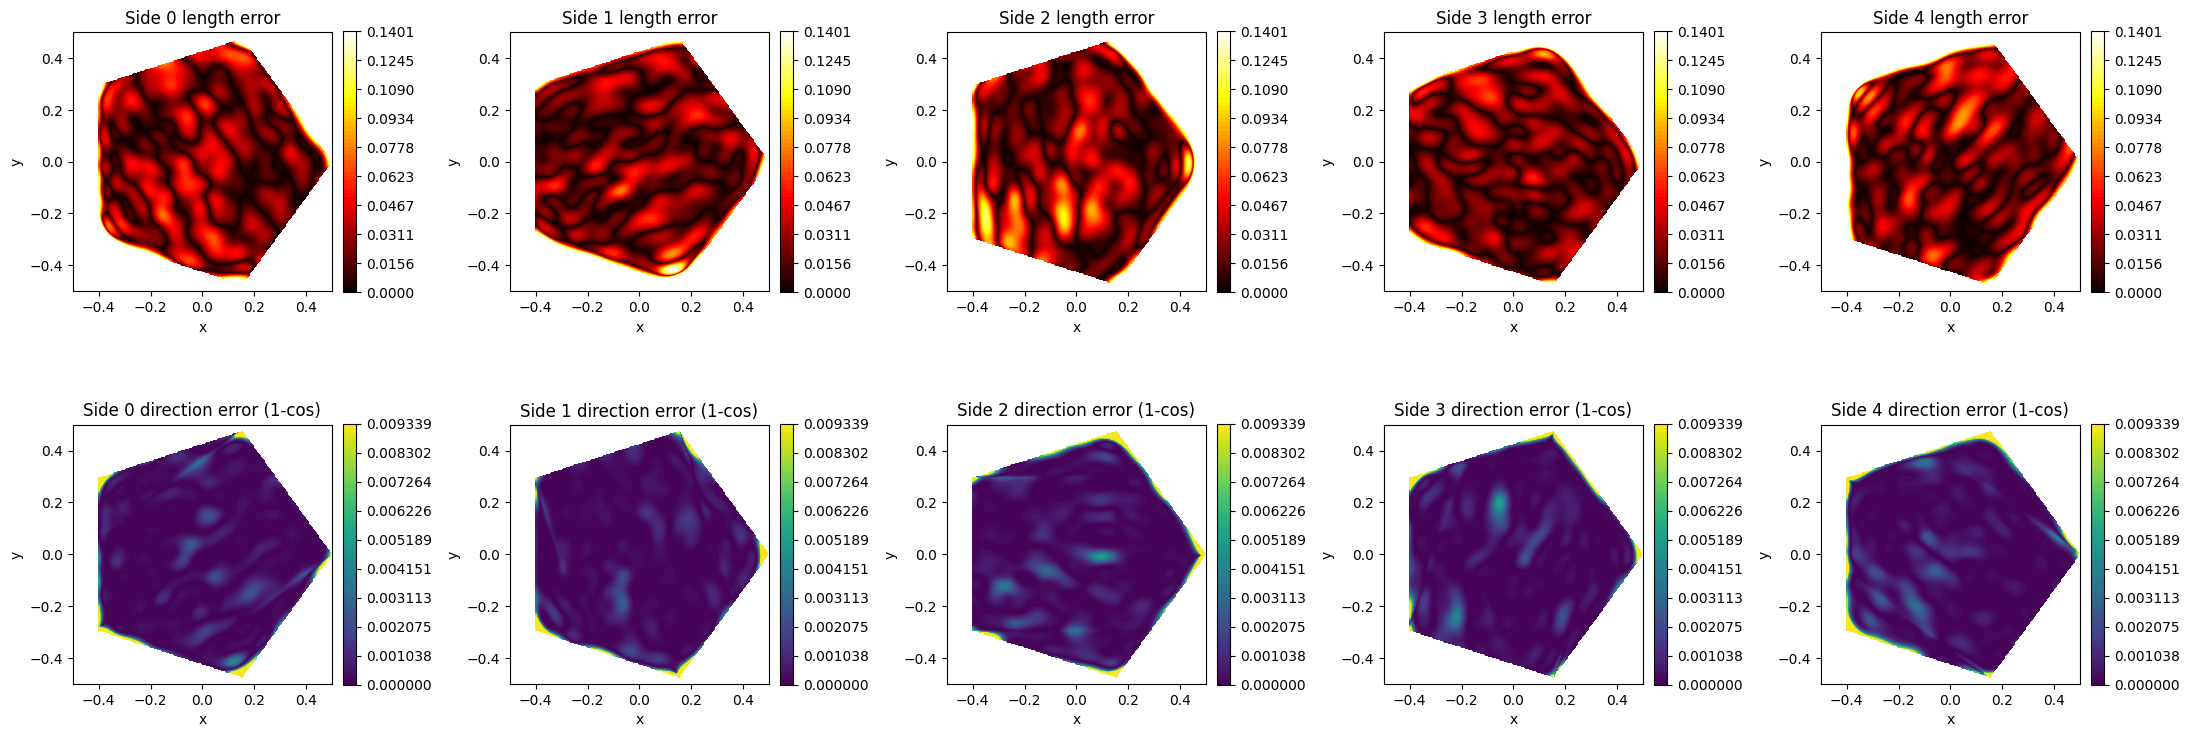

In [14]:
_=NI.plot_local_per_side_gradient_length_direction_error_fun1(model=model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

# Eval other type

In [35]:
architecture = [2, 256,256,256,256,5]
model2 = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model2.parameters())}')
model2.optimizer = torch.optim.Adam(model2.parameters(), lr=5e-5)
model2.lr_scheduler = torch.optim.lr_scheduler.StepLR(model2.optimizer, step_size=500, gamma=0.8)


Number of parameters: 199429


In [ ]:
#load saved model
mdl_name = "SIREN_pentagon_MMSDF_e.pth"
model2.load_state_dict(torch.load(mdl_name))
model2.eval()

C:\Users\csapo\AppData\Local\Temp\ipykernel_27892\4048785707.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load(mdl_name))


Siren_jo(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (4): Linear(in_features=256, out_features=5, bias=True)
  )
)

In [78]:

    #mdl_name = model_names[i].replace(" ", "_").replace("=", "").replace(",", "_") + ".pth"
mdl_name = "SIREN_pentagon_MSSDF_02.pth"
torch.save(model.state_dict(), mdl_name)

In [37]:
NI.evaluate_model_random_points(model2, function_case=1,N=30000)

Model evaluation on N=30000 random points (function_case=1):
  Value errors: mean_abs=4.471201e-05, max_abs=3.109933e-03, L2=9.478735e-05
  Grad-norm errors (|grad|-1): mean_abs=2.325031e-03, max_abs=1.617583e-01, L2=4.326517e-03
  Hessian-diagonal errors (target 0): mean_abs=4.405954e-01, max_abs=1.543182e+01, L2=1.021493e+00
  General (closest-side) errors: MAE=3.936649e-05, L_inf=1.065482e-03


{'N': 30000,
 'function_case': 1,
 'global': {'value_mean_abs_error': 4.471200708616564e-05,
  'value_max_abs_error': 0.003109933215937659,
  'value_l2_error': 9.47873491049966e-05,
  'grad_norm_mean_abs_error': 0.0023250311414897205,
  'grad_norm_max_abs_error': 0.16175826238501778,
  'grad_norm_l2_error': 0.004326516999554364,
  'hessian_diag_mean_abs_error': 0.4405954210536268,
  'hessian_diag_max_abs_error': 15.431824963541635,
  'hessian_diag_l2_error': 1.0214933825784627,
  'general_closest_side_mae': 3.936648916946886e-05,
  'general_closest_side_l_inf': 0.001065482056336376}}

In [23]:
architecture = [2, 256,256,256,256,5]
model = net_defs.NeuralNetwork(architecture=architecture)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 199429


In [24]:
importlib.reload(NI)
NUM_EPOCHS = 10000
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.41409069365609313, Acc: 0.41409069365609313
Epoch [999], Loss: 0.005437876747774358, Acc: 0.005437876747774358
Epoch [1999], Loss: 0.0029593874201677465, Acc: 0.0029593874201677465
Epoch [2999], Loss: 0.001329431868003047, Acc: 0.001329431868003047
Epoch [3999], Loss: 0.0004221048855007287, Acc: 0.0004221048855007287
Epoch [4999], Loss: 0.00036440465225695236, Acc: 0.00036440465225695236
Epoch [5999], Loss: 0.0003425001265643519, Acc: 0.0003425001265643519
Epoch [6999], Loss: 0.00030933865912607396, Acc: 0.00030933865912607396
Epoch [7999], Loss: 0.00029578833297519105, Acc: 0.00029578833297519105
Epoch [8999], Loss: 0.00029100163028343855, Acc: 0.00029100163028343855
Epoch [9999], Loss: 0.0002814081487720561, Acc: 0.0002814081487720561


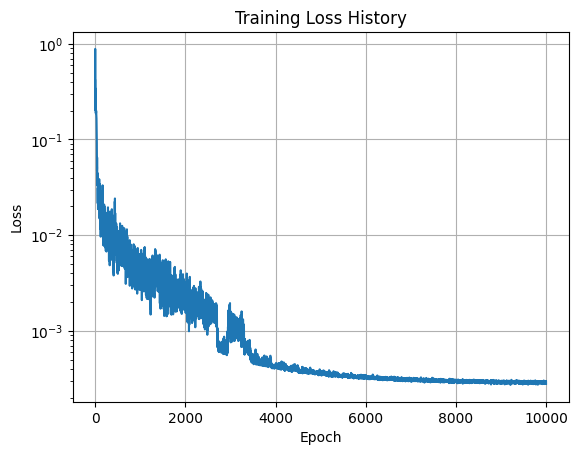

In [25]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [26]:
importlib.reload(NI)
NI.evaluate_model_random_points(model, function_case=1,N=10000)

Model evaluation on N=10000 random points (function_case=1):
  Value errors: mean_abs=2.894504e-04, max_abs=4.468902e-03, L2=4.150935e-04
  Grad-norm errors (|grad|-1): mean_abs=2.797347e-02, max_abs=3.430560e-01, L2=3.955149e-02
  Hessian-diagonal errors (target 0): mean_abs=0.000000e+00, max_abs=0.000000e+00, L2=0.000000e+00


{'N': 10000,
 'function_case': 1,
 'global': {'value_mean_abs_error': 0.0002894503537203808,
  'value_max_abs_error': 0.004468902227195898,
  'value_l2_error': 0.0004150934828172728,
  'grad_norm_mean_abs_error': 0.027973468681709673,
  'grad_norm_max_abs_error': 0.34305600558284177,
  'grad_norm_l2_error': 0.03955149497049091,
  'hessian_diag_mean_abs_error': 0.0,
  'hessian_diag_max_abs_error': 0.0,
  'hessian_diag_l2_error': 0.0}}

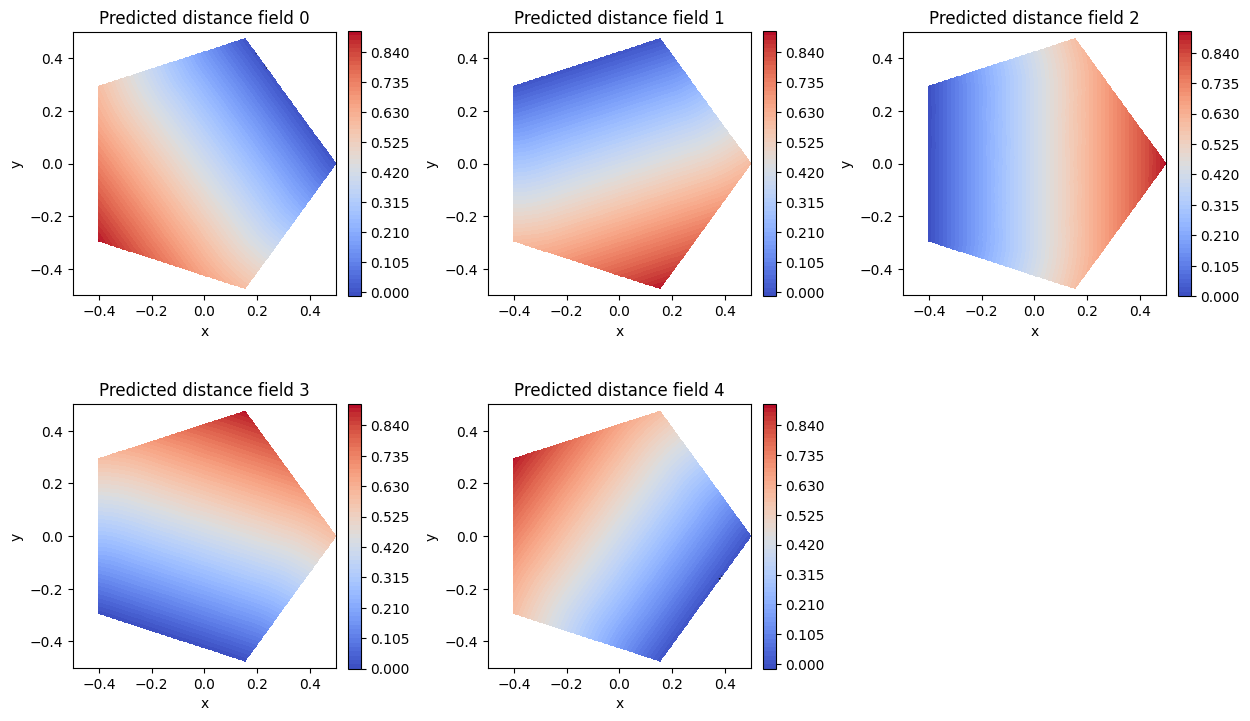

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Predicted distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Predicted distance field 1'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Predicted distance field 2'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Predicted distance field 3'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Predicted distance field 4'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[ 1.09090799,  0.78118143, -0.00687023, -0.15758734,  0.6031304 ],
        [ 1.08940233,  0.77867344, -0.00790411, -0.15565643,  0.60401227],
        [ 1.08788688,  0.77599955, -0.00905984, -0.15375078,  0.60499817],
        ...,
        [-0.24100265,  0.16316939,  0.90942613,  1.01061052,  0.38592128],
        [-0.24196223,  0.16128355,  0.90989395,  1.0128773 ,  0.38786592],
        [-0.24290936,  0.15935927,  0.91033051,  1.01514667,  0.38984658]]))

In [27]:
NI.plot_nn_distance_fields(model,extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

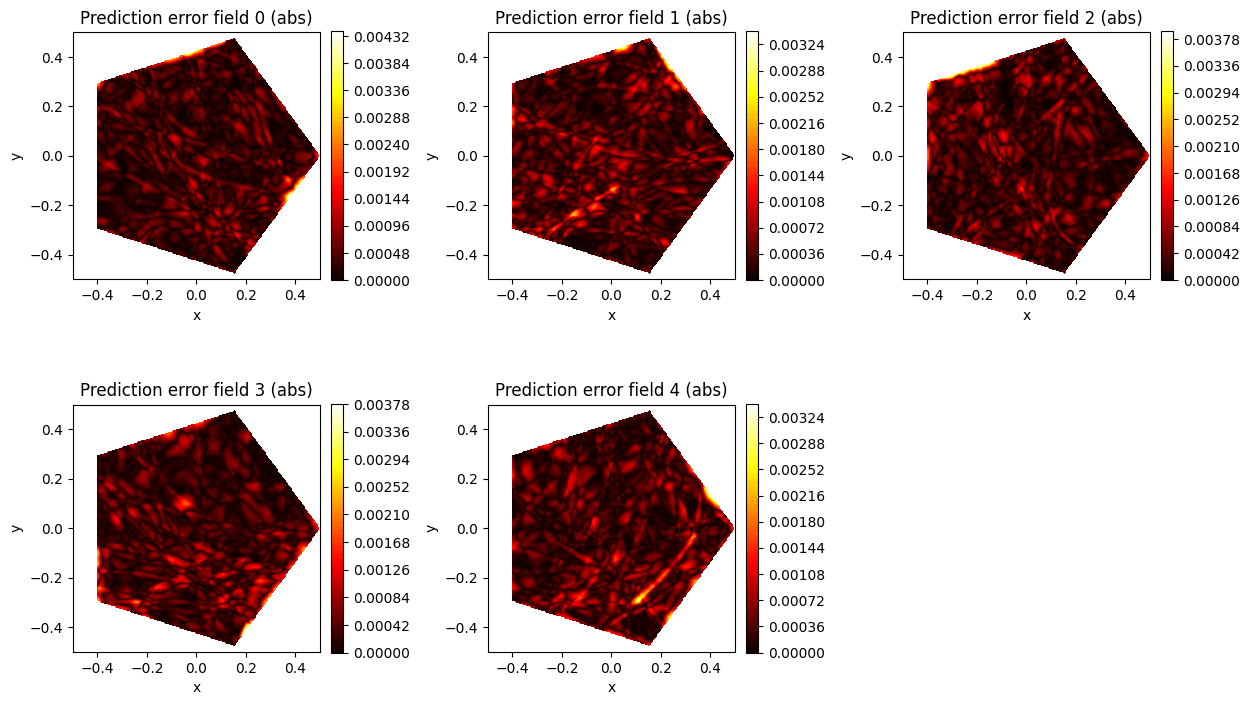

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Prediction error field 0 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Prediction error field 1 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Prediction error field 2 (abs)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Prediction error field 3 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Prediction error field 4 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.01200163, 0.01843356, 0.23402409, 0.3847412 , 0.05183543],
        [0.01207673, 0.01864015, 0.23167009, 0.37634557, 0.04979412],
        [0.01219571, 0.01908449, 0.22947921, 0.36801063, 0.04767408],
        ...,
        [0.52691686, 0.17877678, 0.01690848, 0.0193032 , 0.10788098],
        [0.53193657, 0.18286007, 0.01716704, 0.01956621, 0.10906282],
        [0.53680199, 0.18699783, 0.01736334, 0.01975418, 0.11015342]]))

In [28]:
NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

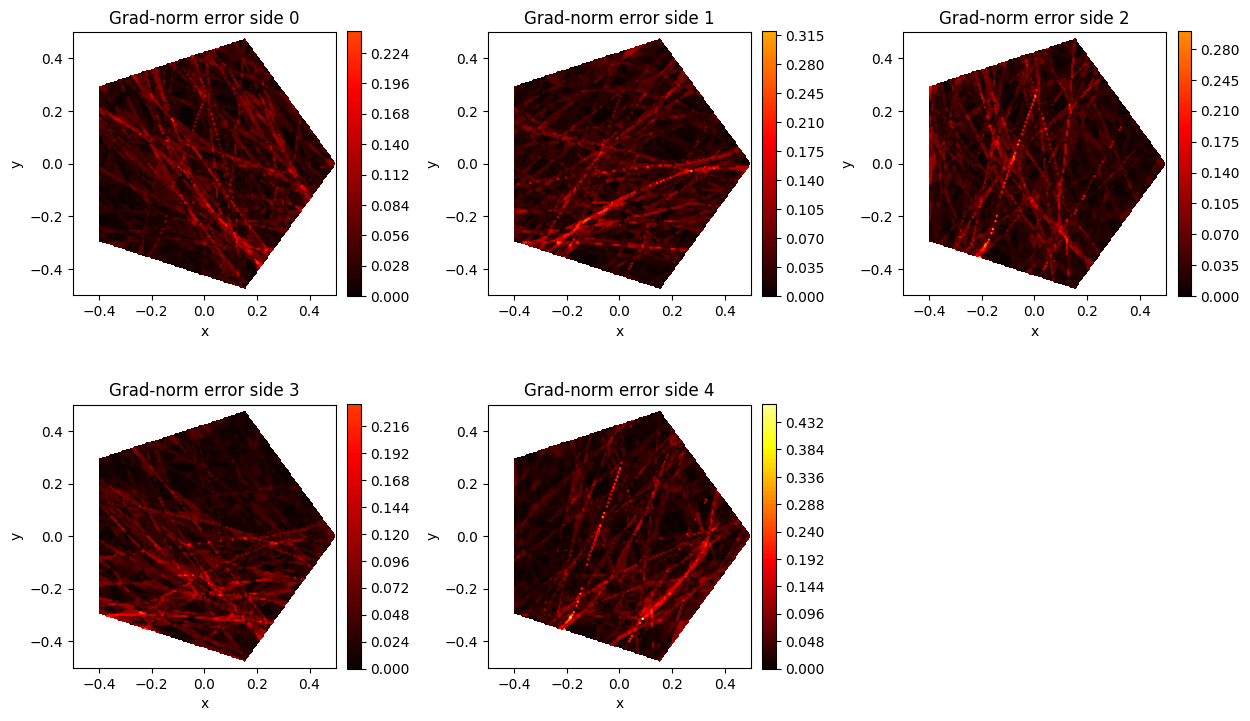

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Grad-norm error side 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Grad-norm error side 1'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Grad-norm error side 2'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Grad-norm error side 3'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Grad-norm error side 4'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[0.0682159 , 0.00800749, 0.04500643, 0.23554964, 0.02069208],
         [0.06040038, 0.09353269, 0.0357807 , 0.23920809, 0.04533342],
         [0.0592654 , 0.09046305, 0.03373037, 0.24137182, 0.04338621],
         ...,
         [0.09752527, 0.16441488, 0.1246674 , 0.0385799 , 0.03480764],
         [0.08064544, 0.14702189, 0.1141457 , 0.01824967, 0.03521897],
         [0.08057365, 0.14626398, 0.11409052, 0.01711474, 0.03582129]],
 
        [[0.05889235, 0.00902571, 0.04219564, 0.23289062,

In [29]:
NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

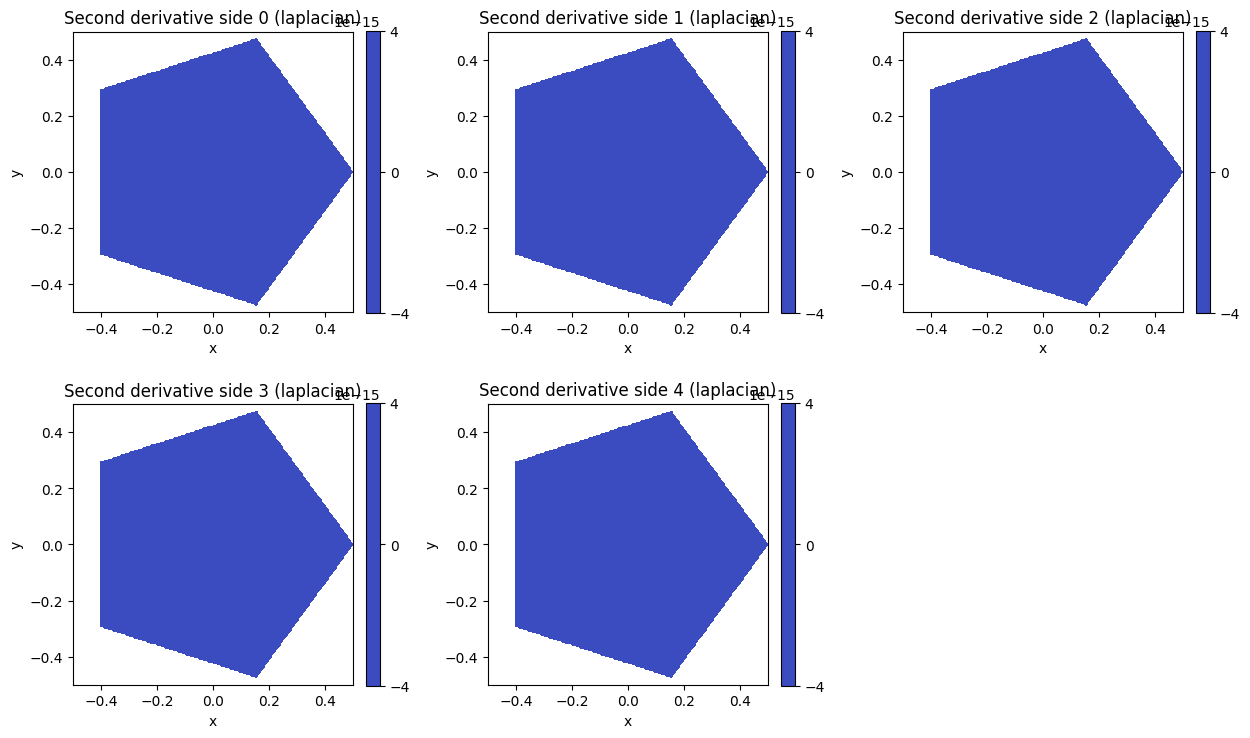

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Second derivative side 0 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 1 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 2 (laplacian)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Second derivative side 3 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 4 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         ...,
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         ...,
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0.

In [30]:
importlib.reload(NI)
NI.plot_local_per_side_second_derivative(model=model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

In [44]:
importlib.reload(net_defs)
architecture = [2, 256,256,256,256,5]
model = net_defs.TSIREN(architecture=architecture, outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 204569


In [54]:
importlib.reload(NI)
NUM_EPOCHS = 4000
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      epsilon=0.0,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 5.634124941387411e-05, Acc: 5.634124941387411e-05
Epoch [399], Loss: 5.7074729730885835e-05, Acc: 5.7074729730885835e-05
Epoch [799], Loss: 5.383521912240126e-05, Acc: 5.383521912240126e-05
Epoch [1199], Loss: 5.3713496574112646e-05, Acc: 5.3713496574112646e-05
Epoch [1599], Loss: 5.665913452978273e-05, Acc: 5.665913452978273e-05
Epoch [1999], Loss: 5.793381336989884e-05, Acc: 5.793381336989884e-05
Epoch [2399], Loss: 5.7755029237123036e-05, Acc: 5.7755029237123036e-05
Epoch [2799], Loss: 5.355912783971914e-05, Acc: 5.355912783971914e-05
Epoch [3199], Loss: 5.6369943965299246e-05, Acc: 5.6369943965299246e-05
Epoch [3599], Loss: 5.697294310823979e-05, Acc: 5.697294310823979e-05
Epoch [3999], Loss: 5.237445169521902e-05, Acc: 5.237445169521902e-05


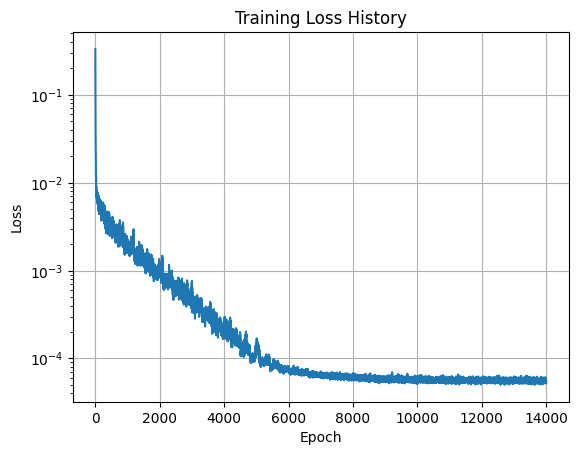

In [55]:
#plo
plt.plot(model.loss_history)
plt.yscale('log')
#plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [53]:
NI.evaluate_model_random_points(model=model, function_case=1,N=30000)

Model evaluation on N=30000 random points (function_case=1):
  Value errors: mean_abs=5.716255e-05, max_abs=4.510846e-03, L2=1.102893e-04
  Grad-norm errors (|grad|-1): mean_abs=3.629133e-03, max_abs=4.505698e-01, L2=1.067407e-02
  Hessian-diagonal errors (target 0): mean_abs=4.975234e-01, max_abs=2.325141e+01, L2=1.091634e+00
  General (closest-side) errors: MAE=4.251313e-05, L_inf=2.118029e-03


{'N': 30000,
 'function_case': 1,
 'global': {'value_mean_abs_error': 5.716254677985337e-05,
  'value_max_abs_error': 0.004510845835047683,
  'value_l2_error': 0.0001102892869314771,
  'grad_norm_mean_abs_error': 0.0036291334249700913,
  'grad_norm_max_abs_error': 0.45056977786853125,
  'grad_norm_l2_error': 0.010674070758812531,
  'hessian_diag_mean_abs_error': 0.49752342947313094,
  'hessian_diag_max_abs_error': 23.251409591706498,
  'hessian_diag_l2_error': 1.0916342538245625,
  'general_closest_side_mae': 4.2513126199436566e-05,
  'general_closest_side_l_inf': 0.002118028568384292}}

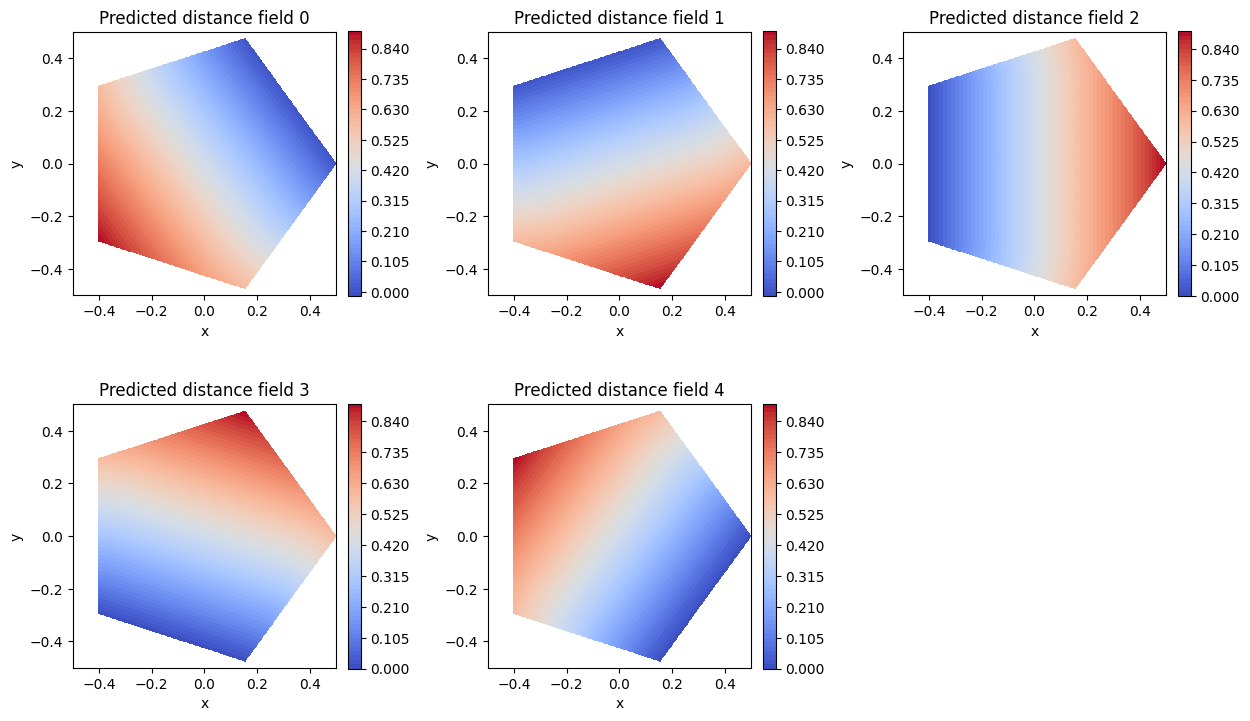

In [52]:
_=NI.plot_nn_distance_fields(model=model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

In [ ]:
_

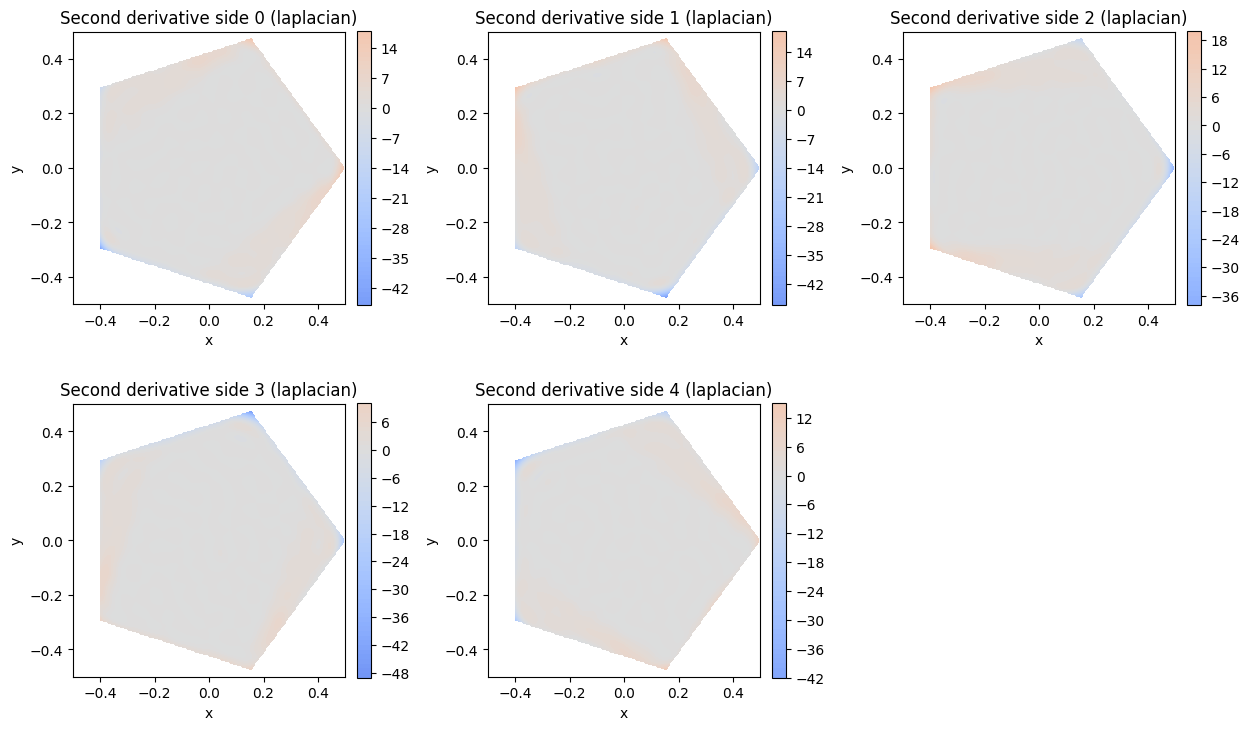

(<Figure size 1260x760 with 11 Axes>,
 array([[<Axes: title={'center': 'Second derivative side 0 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 1 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 2 (laplacian)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Second derivative side 3 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 4 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[  9.73167085,  -1.88255754,  -4.43376464,   4.974579  ,
           15.16541134],
         [  9.10528084,  -2.97833377,  -3.82530093,   4.89254729,
           14.73665378],
         [  8.43383088,  -4.07047693,  -3.40077766,   4.4249479 ,
           13.91524369],
         ...,
         [ -0.30335421,  -9.49442182, -24.31386377,  -8.34802202,
            3.27946558],
         [ -0.30298584,  -9.38463407, -24.40030133, 

In [48]:
NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'))

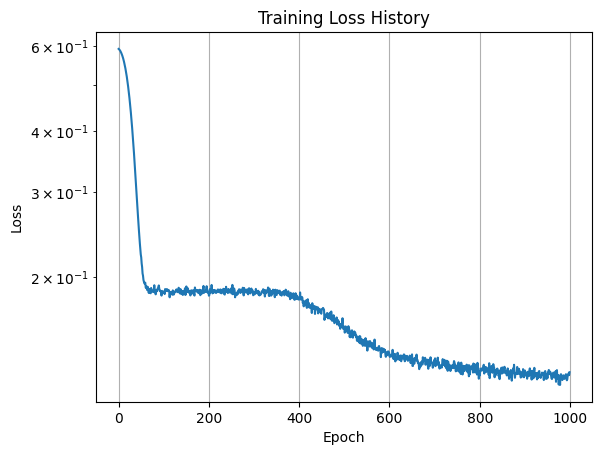

In [43]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [220]:
learning_stats.append({"architecture": architecture, "loss_history": model.loss_history, "num_parameters": sum(p.numel() for p in model.parameters())})

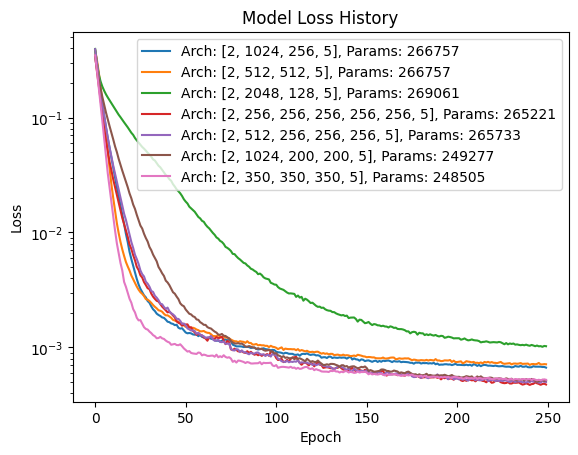

In [221]:
for i in range(len(learning_stats)):
    #apply moving average to smooth the loss curve
    window_size = 20
    smoothed_loss = [sum(learning_stats[i]["loss_history"][j:j+window_size]) / window_size for j in range(0, len(learning_stats[i]["loss_history"]), window_size)]
    plt.plot(smoothed_loss, label=f'Arch: {learning_stats[i]["architecture"]}, Params: {learning_stats[i]["num_parameters"]}')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss History')
plt.yscale('log')

In [365]:
importlib.reload(net_defs)
architecture = [2, 256,256]
subarchitecture = [256,110,1]
model = net_defs.ForkSIREN(num_sides=5, mutual_architecture=architecture, subarchitecture=subarchitecture, outermost_linear=True, first_omega_0=20, hidden_omega_0=20)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 208465


In [368]:
importlib.reload(NI)
NUM_EPOCHS = 2500
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0, 
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True,
                      device=torch.device('cpu'))



Epoch [0], Loss: 8.329678240544293e-05, Acc: 8.329678240544293e-05
Epoch [249], Loss: 7.808160724970136e-05, Acc: 7.808160724970136e-05
Epoch [499], Loss: 7.624368787535441e-05, Acc: 7.624368787535441e-05
Epoch [749], Loss: 8.987241380061106e-05, Acc: 8.987241380061106e-05
Epoch [999], Loss: 8.789313447329851e-05, Acc: 8.789313447329851e-05
Epoch [1249], Loss: 7.882123737646227e-05, Acc: 7.882123737646227e-05
Epoch [1499], Loss: 7.830505284158124e-05, Acc: 7.830505284158124e-05
Epoch [1749], Loss: 8.275505712539751e-05, Acc: 8.275505712539751e-05
Epoch [1999], Loss: 7.945374150564054e-05, Acc: 7.945374150564054e-05
Epoch [2249], Loss: 7.704168296928209e-05, Acc: 7.704168296928209e-05
Epoch [2499], Loss: 8.59745692099238e-05, Acc: 8.59745692099238e-05


In [375]:
importlib.reload(net_defs)

subarchitecture = [2,256,150,1]
model = net_defs.Parallel_SIREN(num_sides=5, subarchitecture=subarchitecture, outermost_linear=True, first_omega_0=20, hidden_omega_0=20)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 197345


In [377]:
importlib.reload(NI)
NUM_EPOCHS = 2500
BATCH_SIZE = 1024
FUN_NUM = 1
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0, 
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True,
                      device=torch.device('cpu'))



Epoch [0], Loss: 0.0007753876962112029, Acc: 0.0007753876962112029
Epoch [249], Loss: 0.0007550141233168741, Acc: 0.0007550141233168741
Epoch [499], Loss: 0.0007842076043491616, Acc: 0.0007842076043491616
Epoch [749], Loss: 0.0007271375223560177, Acc: 0.0007271375223560177
Epoch [999], Loss: 0.000777568285720313, Acc: 0.000777568285720313
Epoch [1249], Loss: 0.0007649961677512606, Acc: 0.0007649961677512606
Epoch [1499], Loss: 0.0007915261775302999, Acc: 0.0007915261775302999
Epoch [1749], Loss: 0.0007680182523266599, Acc: 0.0007680182523266599
Epoch [1999], Loss: 0.0007528808933591408, Acc: 0.0007528808933591408
Epoch [2249], Loss: 0.0007399353966467891, Acc: 0.0007399353966467891
Epoch [2499], Loss: 0.0007323893262525307, Acc: 0.0007323893262525307


In [70]:
import contextlib
import io
import random
import time
import numpy as np
import pandas as pd

importlib.reload(NI)
importlib.reload(net_defs)

device = torch.device('cpu')
FUN_NUM = 1
TRAIN_EPOCHS = 600
BATCH_SIZE = 1024
VAL_RESOLUTION = 96
SEED = 1234

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

grid = torch.linspace(-0.5, 0.5, VAL_RESOLUTION, device=device)
X, Y = torch.meshgrid(grid, grid)
val_pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
val_target = NI._evaluate_ground_truth_on_points(
    val_pts,
    fun_num=FUN_NUM,
    data_gen_params={'n_sides': 5, 'radius': 0.5, 'center': (0.0, 0.0), 'rotation': 0.0},
 )

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def evaluate_model(model):
    model.to(device)
    model.eval()
    with torch.no_grad():
        pred = model(val_pts)
        abs_err = torch.abs(pred - val_target)
        sq_err = (pred - val_target) ** 2
    return {
        'val_l1': abs_err.mean().item(),
        'val_l2': torch.sqrt(sq_err.mean()).item(),
        'val_linf': abs_err.max().item(),
    }

def train_and_score(name, model_factory, lr):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    model = model_factory()
    model.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    started = time.time()
    with contextlib.redirect_stdout(io.StringIO()):
        NI.train_model_simple(
            model,
            num_epochs=TRAIN_EPOCHS,
            batch_size=BATCH_SIZE,
            fun_num=FUN_NUM,
            boundary_error_coeff=0.0,
            device=device,
        )
    metrics = evaluate_model(model)
    metrics['name'] = name
    metrics['params'] = count_parameters(model)
    metrics['final_train_loss'] = model.loss_history[-1]
    metrics['seconds'] = round(time.time() - started, 1)
    metrics['model'] = model
    return metrics

experiments = [
    ('Fork 256x128 + 128x128, omega20 lr5e-6', lambda: net_defs.ForkSIREN(num_sides=5, mutual_architecture=[2, 256, 128], subarchitecture=[128, 128, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 5e-6, 20, 20),
    ('Fork 384x192 + 192x128, omega20 lr3e-6', lambda: net_defs.ForkSIREN(num_sides=5, mutual_architecture=[2, 384, 192], subarchitecture=[192, 128, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 3e-6, 20, 20),
    ('Fork 512x256 + 256x128, omega20 lr2e-6', lambda: net_defs.ForkSIREN(num_sides=5, mutual_architecture=[2, 512, 256], subarchitecture=[256, 128, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 2e-6, 20, 20),
    ('Fork 384x256 + 256x128, omega30 lr2e-6', lambda: net_defs.ForkSIREN(num_sides=5, mutual_architecture=[2, 384, 256], subarchitecture=[256, 128, 1], outermost_linear=True, first_omega_0=30, hidden_omega_0=30), 2e-6, 30, 30),
    ('Parallel 128x64, omega20 lr5e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 128, 64, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 5e-6, 20, 20),
    ('Parallel 256x128, omega20 lr5e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 256, 128, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 5e-6, 20, 20),
    ('Parallel 256x256, omega10 lr3e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 256, 256, 1], outermost_linear=True, first_omega_0=10, hidden_omega_0=10), 3e-6, 10, 10),
    ('Parallel 256x256, omega20 lr3e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 256, 256, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 3e-6, 20, 20),
    ('Parallel 256x256, omega30 lr2e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 256, 256, 1], outermost_linear=True, first_omega_0=30, hidden_omega_0=30), 2e-6, 30, 30),
    ('Parallel 384x256, omega20 lr2e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 384, 256, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 2e-6, 20, 20),
    ('Parallel 512x256, omega20 lr2e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 512, 256, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 2e-6, 20, 20),
    ('Parallel 256x256x256, omega20 lr2e-6', lambda: net_defs.Parallel_SIREN(num_sides=5, subarchitecture=[2, 256, 256, 256, 1], outermost_linear=True, first_omega_0=20, hidden_omega_0=20), 2e-6, 20, 20),
]

results = []
for name, factory, lr, first_omega_0, hidden_omega_0 in experiments:
    print(f'Training {name} ...')
    result = train_and_score(name, factory, lr)
    results.append(result)
    print(f"  final_train_loss={result['final_train_loss']:.6f}, val_l1={result['val_l1']:.6f}, val_l2={result['val_l2']:.6f}, val_linf={result['val_linf']:.6f}")

results_df = pd.DataFrame(results).sort_values('val_l1').reset_index(drop=True)
display(results_df[['name', 'params', 'final_train_loss', 'val_l1', 'val_l2', 'val_linf', 'seconds']])

best_row = results_df.iloc[0]
best_model = best_row['model']
print('Best architecture by validation L1:')
print(f"  {best_row['name']}")
print(f"  params={int(best_row['params'])}, final_train_loss={best_row['final_train_loss']:.6f}, val_l1={best_row['val_l1']:.6f}, val_l2={best_row['val_l2']:.6f}, val_linf={best_row['val_linf']:.6f}")


Training Fork 256x128 + 128x128, omega20 lr5e-6 ...
  final_train_loss=0.006893, val_l1=0.007190, val_l2=0.025131, val_linf=0.305277
Training Fork 384x192 + 192x128, omega20 lr3e-6 ...
  final_train_loss=0.015612, val_l1=0.015814, val_l2=0.045623, val_linf=0.382752
Training Fork 512x256 + 256x128, omega20 lr2e-6 ...
  final_train_loss=0.016564, val_l1=0.017010, val_l2=0.049060, val_linf=0.418707
Training Fork 384x256 + 256x128, omega30 lr2e-6 ...
  final_train_loss=0.045642, val_l1=0.045693, val_l2=0.100626, val_linf=0.549476
Training Parallel 128x64, omega20 lr5e-6 ...
  final_train_loss=0.053691, val_l1=0.052884, val_l2=0.112646, val_linf=0.742131
Training Parallel 256x128, omega20 lr5e-6 ...
  final_train_loss=0.004766, val_l1=0.004959, val_l2=0.019661, val_linf=0.325743
Training Parallel 256x256, omega10 lr3e-6 ...
  final_train_loss=0.003380, val_l1=0.003699, val_l2=0.008085, val_linf=0.160088
Training Parallel 256x256, omega20 lr3e-6 ...
  final_train_loss=0.001617, val_l1=0.0018

,name,params,final_train_loss,val_l1,val_l2,val_linf,seconds
0,"Parallel 256x256, omega20 lr3e-6",663045,0.001617,0.001896,0.007020,0.277615,29.5
1,"Parallel 256x256x256, omega20 lr2e-6",992005,0.001673,0.002045,0.008306,0.226583,40.1
2,"Parallel 512x256, omega20 lr2e-6",994565,0.001985,0.002519,0.010343,0.313236,44.9
3,"Parallel 384x256, omega20 lr2e-6",828805,0.002959,0.003312,0.012860,0.308735,36.1
4,"Parallel 256x256, omega10 lr3e-6",663045,0.003380,0.003699,0.008085,0.160088,29.5
5,"Parallel 256x128, omega20 lr5e-6",251525,0.004766,0.004959,0.019661,0.325743,19.5
6,"Fork 256x128 + 128x128, omega20 lr5e-6",199429,0.006893,0.007190,0.025131,0.305277,19.7
7,"Parallel 256x256, omega30 lr2e-6",663045,0.009999,0.010756,0.037524,0.462329,30.0
8,"Fork 384x192 + 192x128, omega20 lr3e-6",281797,0.015612,0.015814,0.045623,0.382752,17.2
9,"Fork 512x256 + 256x128, omega20 lr2e-6",380549,0.016564,0.017010,0.049060,0.418707,20.5


Best architecture by validation L1:
  Parallel 256x256, omega20 lr3e-6
  params=663045, final_train_loss=0.001617, val_l1=0.001896, val_l2=0.007020, val_linf=0.277615


In [305]:
import itertools
import contextlib
import io
import random
import time
import numpy as np
import pandas as pd

importlib.reload(NI)
importlib.reload(net_defs)

device = torch.device('cpu')
FUN_NUM = 1
TRAIN_EPOCHS = 600
BATCH_SIZE = 1024
SEED = 1234
VAL_RESOLUTION = 96
TARGET_PARAMS = 200000
ARCHS_PER_FAMILY = 4
MAX_PARAM_GAP = 60000

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

grid = torch.linspace(-0.5, 0.5, VAL_RESOLUTION, device=device)
X, Y = torch.meshgrid(grid, grid)
val_pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)
val_target = NI._evaluate_ground_truth_on_points(
    val_pts,
    fun_num=FUN_NUM,
    data_gen_params={'n_sides': 5, 'radius': 0.5, 'center': (0.0, 0.0), 'rotation': 0.0},
)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def evaluate_model(model):
    model.to(device)
    model.eval()
    with torch.no_grad():
        pred = model(val_pts)
        abs_err = torch.abs(pred - val_target)
        sq_err = (pred - val_target) ** 2
    return {
        'val_l1': abs_err.mean().item(),
        'val_l2': torch.sqrt(sq_err.mean()).item(),
        'val_linf': abs_err.max().item(),
    }

def build_model_from_spec(spec, first_omega_0, hidden_omega_0):
    model_type = spec['model_type']
    if model_type == 'Siren_jo':
        return net_defs.Siren_jo(
            architecture=[2, spec['w1'], spec['w2'], spec['w3'], 5],
            outermost_linear=True,
            first_omega_0=first_omega_0,
            hidden_omega_0=hidden_omega_0,
        )
    if model_type == 'Parallel_SIREN':
        return net_defs.Parallel_SIREN(
            num_sides=5,
            subarchitecture=[2, spec['w1'], spec['w2'], 1],
            outermost_linear=True,
            first_omega_0=first_omega_0,
            hidden_omega_0=hidden_omega_0,
        )
    return net_defs.ForkSIREN(
        num_sides=5,
        mutual_architecture=[2, spec['mw1'], spec['mw2']],
        subarchitecture=[spec['mw2'], spec['sw1'], 1],
        outermost_linear=True,
        first_omega_0=first_omega_0,
        hidden_omega_0=hidden_omega_0,
    )

def architecture_label(spec):
    if spec['model_type'] == 'Siren_jo':
        return f"[2,{spec['w1']},{spec['w2']},{spec['w3']},5]"
    if spec['model_type'] == 'Parallel_SIREN':
        return f"sub=[2,{spec['w1']},{spec['w2']},1], sides=5"
    return f"mutual=[2,{spec['mw1']},{spec['mw2']}], sub=[{spec['mw2']},{spec['sw1']},1], sides=5"

def candidate_specs():
    specs = []

    # Siren_jo needs wider layers to reach ~200k params.
    for w1 in range(240, 401, 16):
        for w2 in range(240, 401, 16):
            for w3 in range(192, 385, 16):
                specs.append({'model_type': 'Siren_jo', 'w1': w1, 'w2': w2, 'w3': w3})

    for w1 in [128, 144, 160, 176, 192, 208, 224, 240]:
        for w2 in [96, 112, 128, 144, 160, 176, 192]:
            specs.append({'model_type': 'Parallel_SIREN', 'w1': w1, 'w2': w2})

    for mw1 in [80, 96, 112, 128, 144, 160, 176]:
        for mw2 in [112, 128, 144, 160, 176, 192, 208]:
            for sw1 in [80, 96, 112, 128, 144, 160]:
                specs.append({'model_type': 'Fork_SIREN', 'mw1': mw1, 'mw2': mw2, 'sw1': sw1})

    return specs

all_specs = candidate_specs()
arch_rows = []
for spec in all_specs:
    model = build_model_from_spec(spec, first_omega_0=20, hidden_omega_0=20)
    params = count_parameters(model)
    arch_rows.append({
        'model_type': spec['model_type'],
        'arch_label': architecture_label(spec),
        'params': int(params),
        'param_gap': int(abs(params - TARGET_PARAMS)),
        'spec': spec,
    })

arch_df = pd.DataFrame(arch_rows).sort_values(['model_type', 'param_gap', 'params']).reset_index(drop=True)

selected_specs = []
for model_type in ['Siren_jo', 'Parallel_SIREN', 'Fork_SIREN']:
    fam = arch_df[arch_df['model_type'] == model_type]
    fam = fam[fam['param_gap'] <= MAX_PARAM_GAP]
    if len(fam) == 0:
        fam = arch_df[arch_df['model_type'] == model_type].head(ARCHS_PER_FAMILY)
    selected_specs.extend(fam.head(ARCHS_PER_FAMILY).to_dict('records'))

selection_df = pd.DataFrame(selected_specs)[['model_type', 'arch_label', 'params', 'param_gap']]
print('Selected architecture pool near target parameters:')
display(selection_df.sort_values(['model_type', 'param_gap']).reset_index(drop=True))

def train_and_score(config):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = build_model_from_spec(
        config['spec'],
        first_omega_0=config['first_omega_0'],
        hidden_omega_0=config['hidden_omega_0'],
    )
    model.optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    started = time.time()
    with contextlib.redirect_stdout(io.StringIO()):
        NI.train_model_simple(
            model,
            num_epochs=TRAIN_EPOCHS,
            batch_size=BATCH_SIZE,
            fun_num=FUN_NUM,
            boundary_error_coeff=config['boundary_error_coeff'],
            eikon_coeff=config['eikon_coeff'],
            hotspot_coeff=config['hotspot_coeff'],
            use_scheduler=False,
            device=device,
        )

    metrics = evaluate_model(model)
    metrics['model_type'] = config['model_type']
    metrics['arch_label'] = config['arch_label']
    metrics['params'] = count_parameters(model)
    metrics['param_gap'] = abs(metrics['params'] - TARGET_PARAMS)
    metrics['lr'] = config['lr']
    metrics['first_omega_0'] = config['first_omega_0']
    metrics['hidden_omega_0'] = config['hidden_omega_0']
    metrics['boundary_error_coeff'] = config['boundary_error_coeff']
    metrics['eikon_coeff'] = config['eikon_coeff']
    metrics['hotspot_coeff'] = config['hotspot_coeff']
    metrics['final_train_loss'] = model.loss_history[-1]
    metrics['seconds'] = round(time.time() - started, 1)
    return metrics

coeff_space = {
    'lr': [5e-6, 2e-6],
    'first_omega_0': [15, 20],
    'hidden_omega_0': [20, 30],
    'boundary_error_coeff': [0.0,1e-1, 1e-2],
    'eikon_coeff': [0.0,1e-1, 1e-3],
    'hotspot_coeff': [0.0,1e-1, 1e-3],
}

run_configs = []
for row in selected_specs:
    keys = list(coeff_space.keys())
    for values in itertools.product(*(coeff_space[k] for k in keys)):
        base = {k: v for k, v in zip(keys, values)}
        base['model_type'] = row['model_type']
        base['arch_label'] = row['arch_label']
        base['spec'] = row['spec']
        run_configs.append(base)

# Use a small value first; set to None for full sweep.
MAX_SWEEP_RUNS = None
if MAX_SWEEP_RUNS is not None:
    run_configs = run_configs[:MAX_SWEEP_RUNS]
print(f'Total sweep runs: {len(run_configs)}')

sweep_results = []
for idx, config in enumerate(run_configs, start=1):
    print(
        f"[{idx:03d}/{len(run_configs)}] "
        f"model={config['model_type']} | "
        f"arch={config['arch_label']} | "
        f"lr={config['lr']:.1e} | "
        f"omega=({config['first_omega_0']},{config['hidden_omega_0']}) | "
        f"coeffs=(b={config['boundary_error_coeff']:.1e}, e={config['eikon_coeff']:.1e}, h={config['hotspot_coeff']:.1e})"
    )
    sweep_results.append(train_and_score(config))

sweep_df = pd.DataFrame(sweep_results).sort_values(['val_l1', 'param_gap']).reset_index(drop=True)
display(
    sweep_df[[
        'model_type', 'arch_label', 'params', 'param_gap',
        'val_l1', 'val_l2', 'val_linf', 'final_train_loss', 'seconds',
        'lr', 'first_omega_0', 'hidden_omega_0',
        'boundary_error_coeff', 'eikon_coeff', 'hotspot_coeff',
    ]]
)

print('Best configuration by validation L1 (then param-gap tie-break):')
display(sweep_df.iloc[[0]])

Selected architecture pool near target parameters:


,model_type,arch_label,params,param_gap
0,Fork_SIREN,"mutual=[2,144,208], sub=[208,160,1], sides=5",198597,1403
1,Fork_SIREN,"mutual=[2,160,208], sub=[208,160,1], sides=5",201973,1973
2,Fork_SIREN,"mutual=[2,128,208], sub=[208,160,1], sides=5",195221,4779
3,Fork_SIREN,"mutual=[2,176,208], sub=[208,160,1], sides=5",205349,5349
4,Parallel_SIREN,"sub=[2,224,176,1], sides=5",202245,2245
5,Parallel_SIREN,"sub=[2,240,160,1], sides=5",197205,2795
6,Parallel_SIREN,"sub=[2,208,192,1], sides=5",204725,4725
7,Parallel_SIREN,"sub=[2,192,192,1], sides=5",189125,10875
8,Siren_jo,"[2,272,352,288,5]",200021,21
9,Siren_jo,"[2,288,352,272,5]",199973,27


Total sweep runs: 2592
[001/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=0.0e+00, h=0.0e+00)
[002/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=0.0e+00, h=1.0e-01)
[003/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=0.0e+00, h=1.0e-03)
[004/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=1.0e-01, h=0.0e+00)
[005/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=1.0e-01, h=1.0e-01)
[006/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=1.0e-01, h=1.0e-03)
[007/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=1.0e-03, h=0.0e+00)
[008/2592] model=Siren_jo | arch=[2,272,352,288,5] | lr=5.0e-06 | omega=(15,20) | coeffs=(b=0.0e+00, e=1.0e-03, h=1.

KeyboardInterrupt: 